In [1]:
library(tidyverse)
library(lubridate)


source("../theme_ggplot_cfrna.R")
source("../functions.R")
gene_key = read.delim("../gencode.biotype.name.key.tsv")

── Attaching packages ─────────────────────────────────────── tidyverse 1.3.1 ──

✔ ggplot2 3.5.1     ✔ purrr   1.0.2
✔ tibble  3.2.1     ✔ dplyr   1.1.4
✔ tidyr   1.3.1     ✔ stringr 1.5.1
✔ readr   2.1.2     ✔ forcats 0.5.1

── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()


Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union




# Metadata

In [2]:
#############################################
### METADATA
#############################################

mdf = read.delim("../1_DATA/sample_meta_passQC.tsv") %>% filter(ORIGIN == "DFCI")
metrics = read.delim("../1_DATA/metrics_passQC.tsv") %>% unique()
decon = read.delim("../1_DATA/decon_passQC.tsv")

### remove 100 and 24
mdf = mdf %>% filter(!Record_ID %in% c("24"))

### add metrics and decon
mdf <- merge(mdf, metrics, by="sample_id")
mdf <- merge(mdf, decon, by="sample_id")

### factor timepoint
mdf = mdf %>% 
    mutate(timepoint = factor(timepoint, levels = EVENTS)) %>% 
    mutate(timepoint_sym = factor(timepoint_sym, levels = EVENTS_sym)) %>% 
    unique()

mdf$timepoint <- droplevels(mdf$timepoint)
mdf$timepoint_sym <- droplevels(mdf$timepoint_sym)

mdf = mdf %>% 
    mutate(agvhd = case_when(
            !is.na(date_agvhd) & timepoint != "HD" ~ "aGVHD+",
            is.na(date_agvhd) & timepoint != "HD" ~ "aGVHD-",
            timepoint == "HD" ~ "Healthy Donor")) %>%
    mutate(agvhd = factor(agvhd, levels = c("Healthy Donor","aGVHD-","aGVHD+")))

---
# aGVHD - timing

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


Don't know how to automatically pick scale for object of type <difftime>.
Defaulting to continuous.
Don't know how to automatically pick scale for object of type <difftime>.
Defaulting to continuous.


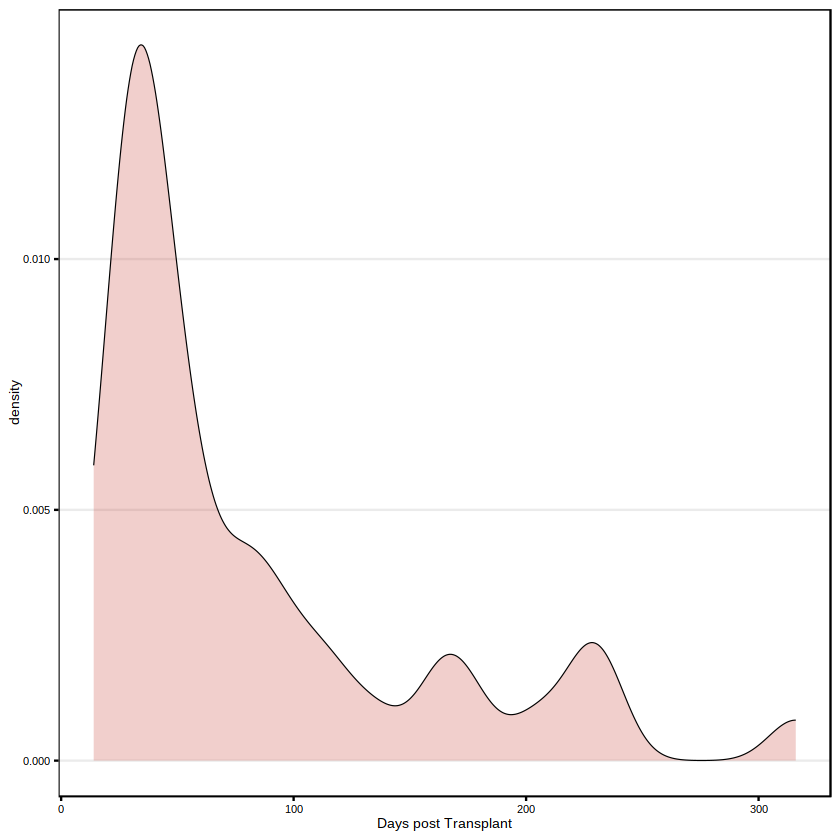

In [ ]:
set.seed(42)

agvhd_timing <- mdf %>%
  select(Record_ID, transplant_date, date_agvhd) %>%
  distinct() %>%
  mutate(
    agvhd_rel_trans = as.numeric(ymd(date_agvhd) - ymd(transplant_date))
  ) %>%
  filter(!is.na(agvhd_rel_trans)) %>%
  ggplot(aes(x = agvhd_rel_trans)) +
  geom_histogram(
    binwidth = 10,                        # adjust bin width as desired
    fill = COLORs[["aGVHD+"]], 
    color = "black", 
    size = 0.25, 
    alpha = 0.5
  ) +
  geom_vline(xintercept = 10, linetype = "dashed", color = "black", size = 0.6) +
  geom_vline(xintercept = 36, linetype = "dashed", color = "black", size = 0.6) +
  scale_y_continuous(breaks = function(limits) seq(0, ceiling(limits[2]), by = 1)) +
  theme_cfrna_print() +
  theme(
    legend.position = "none",
    panel.grid.minor = element_blank(),
    panel.grid.major.x = element_blank(),
    strip.background = element_blank(),
    strip.text = element_blank(),
    axis.text.x = element_text(size = 6, angle = 45, hjust = 1)
  ) +
  labs(
    x = "Days post Transplant",
    y = "Number of Patients"
  )
ggsave("./figures/aGVHD_timing.pdf", width = 2.25, height = 1.54)


---
# pairwise

### Select samples

In [10]:
TIME = c("HD","E","1M","2M","3M","6M")
mdf_agvhd <- mdf %>% 
    filter(timepoint %in% TIME) %>% 
    ## DFCI filters
    # filter(PredEqui_01 == 0 | ORIGIN == "MCC" | timepoint == "HD") %>% 
    ## remove samples with cGVHD
    filter(rel_agvhd < 0 | is.na(rel_agvhd)) %>% 
    mutate(expGroup = ifelse(timepoint %in% c("E","1M"),"E-1M",as.character(timepoint))) %>% 
    mutate(expGroup = factor(expGroup, levels = c("HD","E-1M","2M")))

table(mdf_agvhd$timepoint, !is.na(mdf_agvhd$date_agvhd))

    
     FALSE TRUE
  HD    18    0
  PR     0    0
  D0     0    0
  E     38   33
  1M    39   26
  2M    37   12
  3M    46   11
  6M    43    5

### pairwise comparisons

In [12]:
EXP = "E"

### run wilcoxon tests
all_metrics = c(colnames(metrics),colnames(decon),"simpson")
all_metrics = all_metrics[!all_metrics %in% c("SCALE_qubit")]
# all_metrics = c(colnames(decon))

all_metrics = all_metrics[!all_metrics %in% c("sample_id","Record_ID","timepoint")]

all_res_wilcox = lapply(all_metrics, function(X) {

    g1= mdf_agvhd %>% 
        filter(timepoint == EXP) %>% 
        filter(is.na(date_agvhd)) %>% pull(X) %>% as.numeric()
    g2= mdf_agvhd %>% 
        filter(timepoint == EXP) %>% 
        filter(!is.na(date_agvhd)) %>% pull(X) %>% as.numeric()

    FC= median(g2) / median(g1)
    res = suppressWarnings(wilcox.test(g1,g2))

    return(c(X=X, p=res$p.value, fc = FC)) }
    ) 
    
    
all_res_wilcox = all_res_wilcox %>%  do.call(rbind, .) %>% as.data.frame()

all_res_wilcox$fc = as.numeric(all_res_wilcox$fc)

all_res_wilcox%>% arrange(p) %>% head(20)


,X,p,fc
,<chr>,<chr>,<dbl>
1,intestinal_enteroendocrine_cell_paneth_cell_of_epithelium_of_small_intestine_transit_amplifying_cell_of_small_intestine,0.00388999901684006,1.108570581
2,plasma_cell,0.00874624388859081,9.706909447
3,avgDist_trajectory,0.017172241570789,1.486110593
4,hematopoietic_stem_cell,0.0177348225342573,2.504145502
5,immature_enterocyte_intestinal_crypt_stem_cell_intestinal_crypt_stem_cell_of_small_intestine_transit_amplifying_cell_of_large_intestine,0.0235558519607132,1.052824871
6,leukocyte_decon,0.0309406310816227,1.439066193
7,platelet_activity,0.0405048693486209,NA
8,avgCorrelation_trajectory,0.0489105059519188,0.917407662
9,repHistone_CPM,0.0575720041433112,1.341203384


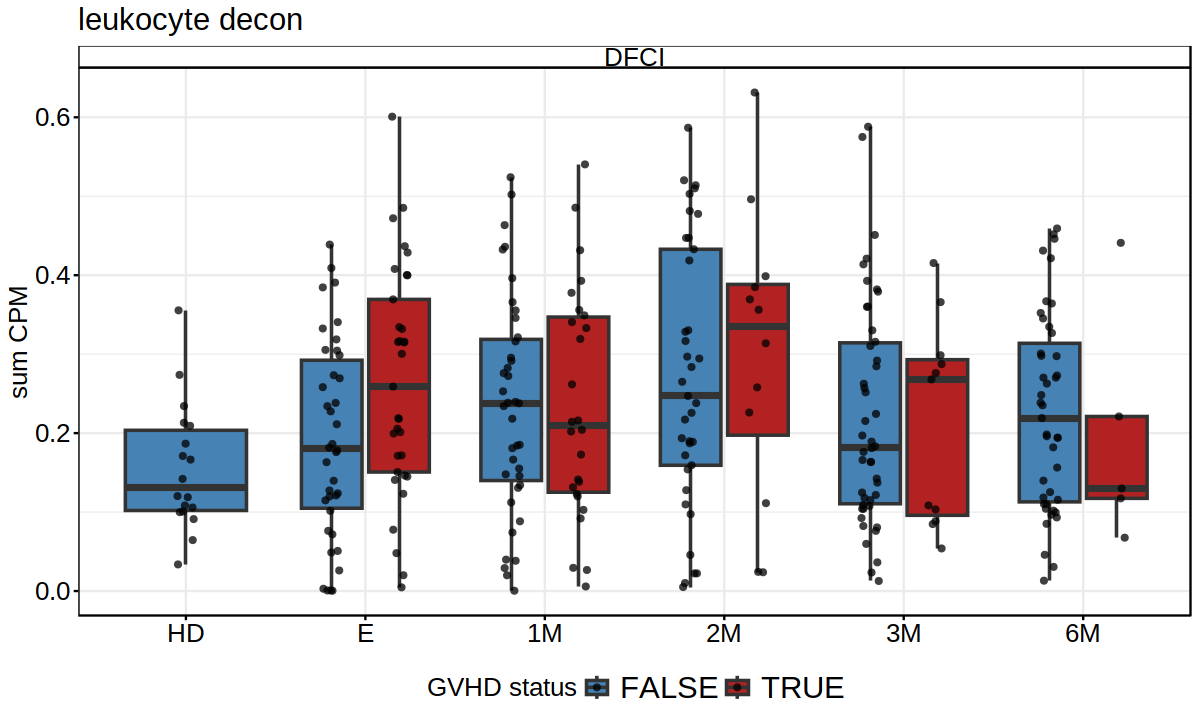

In [26]:
CTs = c("hematopoietic_stem_cell","monocyte","plasma_cell","neutrophil","repHistone_CPM","nonrepHistone_CPM")

VAR = CTs[4]

VAR = "simpson"
VAR = "leukocyte_decon"
# VAR = "platelet_decon"
# VAR = "avgCorrelation_trajectory"
# VAR = "avgDist_trajectory"


options(repr.plot.width=10, repr.plot.height=6)

mdf_agvhd %>% 

    ggplot(aes(x=timepoint, y= !!sym(VAR) , fill =  !is.na(date_agvhd))) +

    geom_boxplot(outlier.shape=NA,size= 0.75)+
    geom_point(position =  position_jitterdodge(jitter.height=0, 
                                                jitter.width=.1, 
                                                seed=42),
                size = 2, alpha = 0.75, stroke=NA)+
    theme_cfrna_slides()+
    labs(title = gsub("_"," ",VAR), y = "sum CPM", x = "Timepoint", fill = "GVHD status")+
    theme(axis.title.x = element_blank(), 
        legend.position = "bottom",
        legend.text = element_text(size = 18))+
    ggh4x::facet_grid2(.~ORIGIN, scales = "free", independent = "y")+
    scale_fill_manual(values = c("FALSE" = "#4682B4", "TRUE" = "#B22222"))


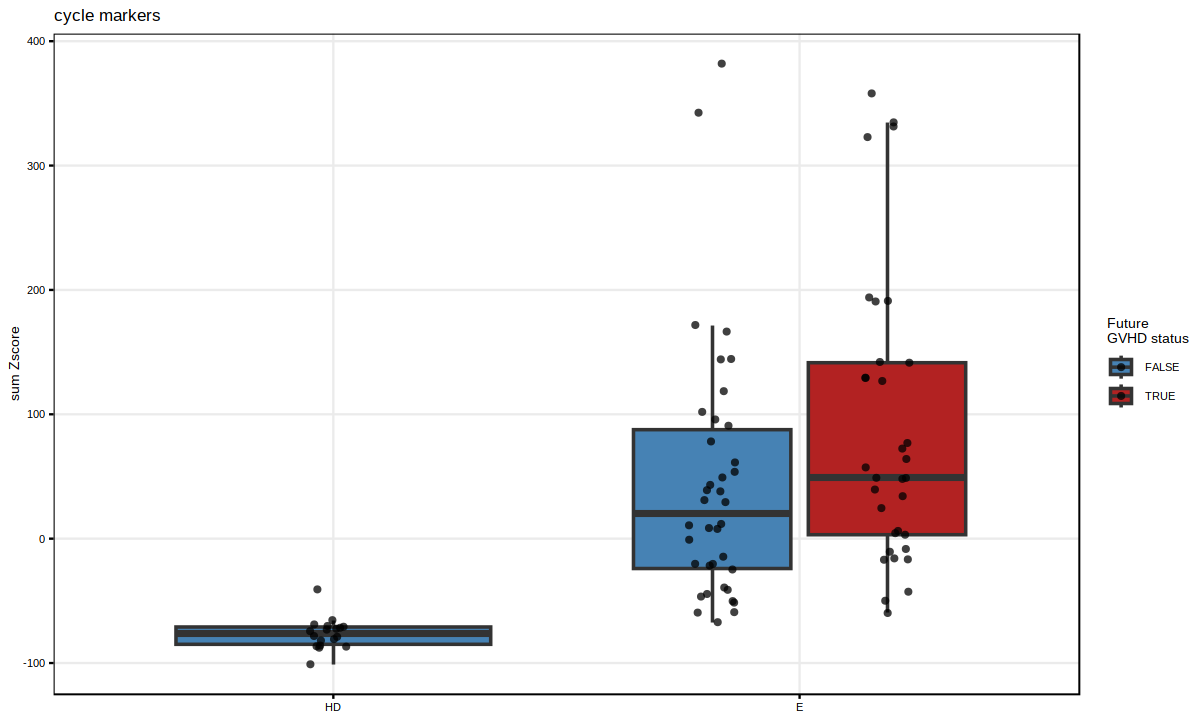

In [22]:
CTs = c("hematopoietic_stem_cell","monocyte","plasma_cell","neutrophil","repHistone_CPM","nonrepHistone_CPM")

VAR = CTs[4]

VAR = "S_Z"
# VAR = "G2M_Z"

VAR = "cycle_markers"


options(repr.plot.width=10, repr.plot.height=6)

mdf_agvhd %>% 
    filter(timepoint %in% c("HD","E")) %>%

    mutate(cycle_markers = G2M_Z + S_Z) %>%

    ggplot(aes(x=timepoint, y= !!sym(VAR) , fill =  !is.na(date_agvhd))) +

    geom_boxplot(outlier.shape=NA,size= 0.75)+
    geom_point(position =  position_jitterdodge(jitter.height=0, 
                                                jitter.width=.1, 
                                                seed=42),
                size = 2, alpha = 0.75, stroke=NA)+
    theme_cfrna_print()+
    labs(title = gsub("_"," ",VAR), y = "sum Zscore", x = "Timepoint", fill = "Future\nGVHD status")+
    theme(axis.title.x = element_blank(), 
        legend.position = "right",
        legend.text = element_text(size = 6))+
    ggh4x::facet_grid2(.~ORIGIN, scales = "free", independent = "y")+
    scale_fill_manual(values = c("FALSE" = "#4682B4", "TRUE" = "#B22222"))


WIDTH = 3.5
HEIGHT = 2.25
ggsave(paste0("./figures/",VAR,"_agvhd.pdf"),width=WIDTH, height = HEIGHT, units = "in")

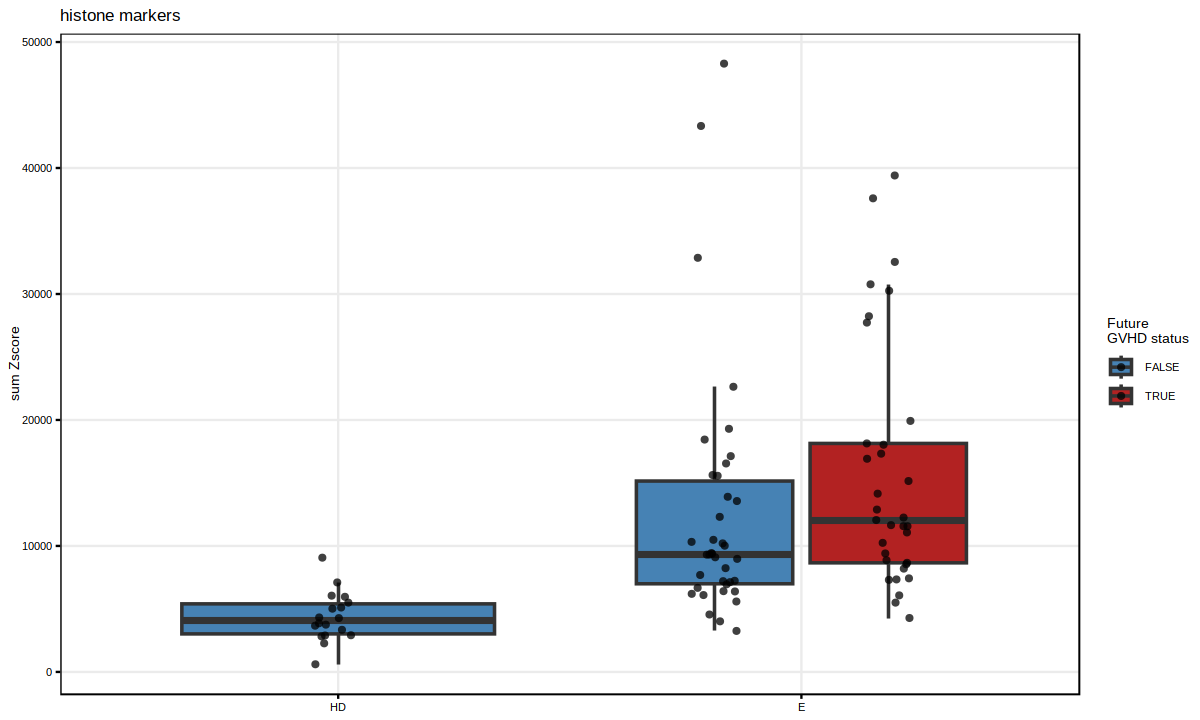

In [27]:
CTs = c("hematopoietic_stem_cell","monocyte","plasma_cell","neutrophil","repHistone_CPM","nonrepHistone_CPM")

VAR = CTs[4]

VAR = "S_Z"
# VAR = "G2M_Z"

VAR = "histone_markers"


options(repr.plot.width=10, repr.plot.height=6)

mdf_agvhd %>% 
    filter(timepoint %in% c("HD","E")) %>%

    mutate(histone_markers = repHistone_CPM + nonrepHistone_CPM) %>%

    ggplot(aes(x=timepoint, y= !!sym(VAR) , fill =  !is.na(date_agvhd))) +

    geom_boxplot(outlier.shape=NA,size= 0.75)+
    geom_point(position =  position_jitterdodge(jitter.height=0, 
                                                jitter.width=.1, 
                                                seed=42),
                size = 2, alpha = 0.75, stroke=NA)+
    theme_cfrna_print()+
    labs(title = gsub("_"," ",VAR), y = "sum Zscore", x = "Timepoint", fill = "Future\nGVHD status")+
    theme(axis.title.x = element_blank(), 
        legend.position = "right",
        legend.text = element_text(size = 6))+
    ggh4x::facet_grid2(.~ORIGIN, scales = "free", independent = "y")+
    scale_fill_manual(values = c("FALSE" = "#4682B4", "TRUE" = "#B22222"))


WIDTH = 3.5
HEIGHT = 2.25
ggsave(paste0("./figures/",VAR,"_agvhd.pdf"),width=WIDTH, height = HEIGHT, units = "in")

In [6]:
t1 = mdf_agvhd %>% 
    filter(timepoint == "E") %>% 
    filter(!is.na(date_agvhd)) %>%
    mutate(histone_markers = repHistone_CPM + nonrepHistone_CPM) %>%
    mutate(cycle_markers = G2M_Z + S_Z) %>%
    pull(histone_markers) %>% as.numeric()
    # pull(cycle_markers) %>% as.numeric()

t2 = mdf_agvhd %>% 
    filter(timepoint == "E") %>% 
    filter(is.na(date_agvhd)) %>%
    mutate(histone_markers = repHistone_CPM + nonrepHistone_CPM) %>%
    mutate(cycle_markers = G2M_Z + S_Z) %>%
    pull(histone_markers) %>% as.numeric()
    # pull(cycle_markers) %>% as.numeric()

wilcox.test(t1,t2)


	Wilcoxon rank sum exact test

data:  t1 and t2
W = 790, p-value = 0.06072
alternative hypothesis: true location shift is not equal to 0


In [13]:
colnames(mdf_agvhd)

[1] "sample_id"                                                                                                                                                                                                                                                   
  [2] "Record_ID"                                                                                                                                                                                                                                                   
  [3] "date"                                                                                                                                                                                                                                                        
  [4] "timepoint"                                                                                                                                                                                                                                                   
  [5] "SCALE_qubit"                                                                                                                                                                                                                                                 
  [6] "sample_group"                                                                                                                                                                                                                                                
  [7] "all_comps"                                                                                                                                                                                                                                                   
  [8] "transplant_date"                                                                                                                                                                                                                                             
  [9] "date_taper_start"                                                                                                                                                                                                                                            
 [10] "date_taper_end"                                                                                                                                                                                                                                              
 [11] "date_agvhd"                                                                                                                                                                                                                                                  
 [12] "date_cgvhd"                                                                                                                                                                                                                                                  
 [13] "ORIGIN"                                                                                                                                                                                                                                                      
 [14] "timepoint_sym"                                                                                                                                                                                                                                               
 [15] "date_Lgvhd"                                                                                                                                                                                                                                                  
 [16] "rel_transplant"                                                                 

In [19]:
baseline = read.csv("../../cfRNA_data/cleaned_clinical_data/baseline_data.csv") %>% 
    select(Record_ID, hct_source, conditioning_regimen)
baseline %>% head

mdf_agvhd_t = merge(mdf_agvhd, baseline, by="Record_ID")

,Record_ID,hct_source,conditioning_regimen
,<int>,<chr>,<chr>
1,13,Peripheral blood,RIC
2,14,Peripheral blood,RIC
3,15,Peripheral blood,RIC
4,16,Peripheral blood,RIC
5,17,Bone marrow,Myeloablative
6,18,Peripheral blood,RIC


Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”


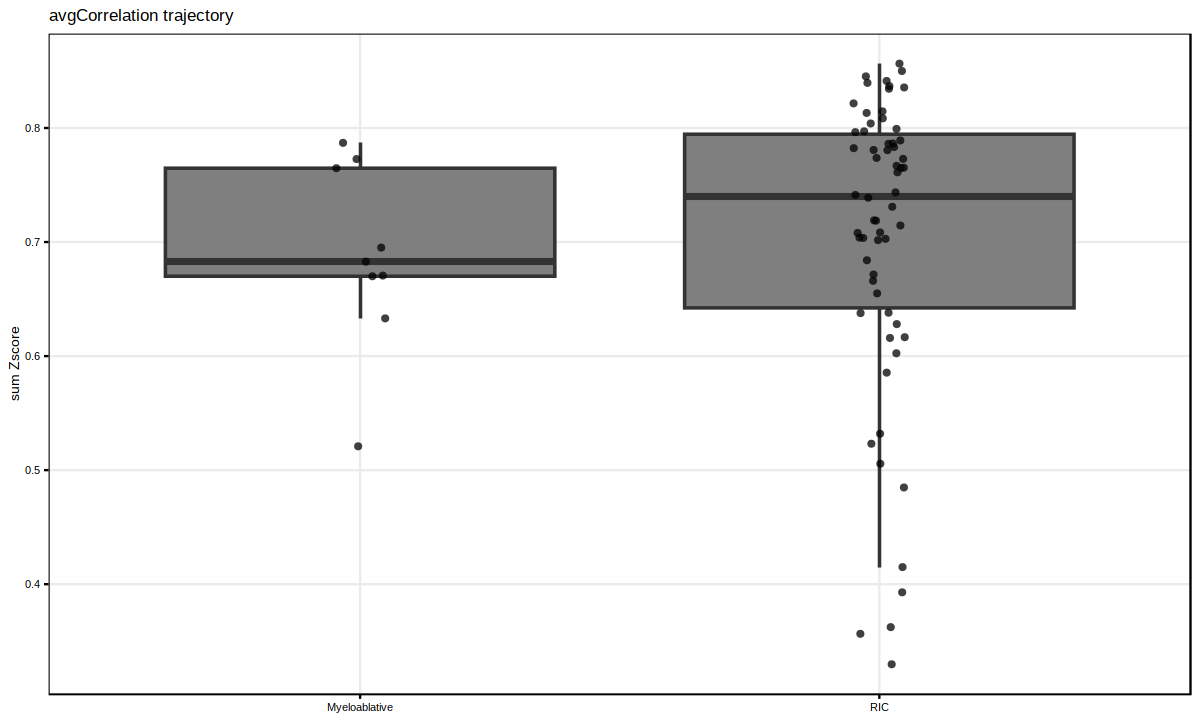

In [22]:
VAR = "avgCorrelation_trajectory"


options(repr.plot.width=10, repr.plot.height=6)

mdf_agvhd_t %>% 
    filter(timepoint %in% c("HD","E")) %>%

    # ggplot(aes(x=timepoint, y= !!sym(VAR) , fill =  !is.na(date_agvhd))) +
    # ggplot(aes(x=hct_source, y= !!sym(VAR) , fill = hct_source )) +
    ggplot(aes(x=conditioning_regimen, y= !!sym(VAR) , fill = conditioning_regimen )) +


    geom_boxplot(outlier.shape=NA,size= 0.75)+
    geom_point(position =  position_jitterdodge(jitter.height=0, 
                                                jitter.width=.1, 
                                                seed=42),
                size = 2, alpha = 0.75, stroke=NA)+
    theme_cfrna_print()+
    labs(title = gsub("_"," ",VAR), y = "sum Zscore", x = "Timepoint", fill = "Future\nGVHD status")+
    theme(axis.title.x = element_blank(), 
        legend.position = "right",
        legend.text = element_text(size = 6))+
    ggh4x::facet_grid2(.~ORIGIN, scales = "free", independent = "y")+
    scale_fill_manual(values = c("FALSE" = "#4682B4", "TRUE" = "#B22222"))


---
# aGVHD - E Decon and Histone

### Select samples

In [4]:
library(cowplot)
library(gridExtra)
library(scales)



TIME = c("HD","E")
mdf_agvhd <- mdf %>% 
    filter(timepoint %in% TIME) %>% 
    filter(rel_agvhd < 0 | is.na(rel_agvhd)) %>% 
    mutate(HIST_ALL = repHistone_CPM + nonrepHistone_CPM)

mdf_agvhd$timepoint <- droplevels(mdf_agvhd$timepoint)
mdf_agvhd$timepoint_sym <- droplevels(mdf_agvhd$timepoint_sym)

table(mdf_agvhd$timepoint, !is.na(mdf_agvhd$date_agvhd))


Attaching package: ‘cowplot’


The following object is masked from ‘package:lubridate’:

    stamp



Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine



Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor




    
     FALSE TRUE
  HD    18    0
  E     38   33

### Wrangle data

In [5]:
CTs  = c("leukocyte_decon", "platelet_decon","simpson", "avgCorrelation_trajectory", "HIST_ALL")
newCT = data.frame(cell_type = CTs,
                    cell_type_label = c("Leukocyte Fraction",
                            "Platelet Fraction" ,
                            "Simpson Index",
                            "Avg Cor to HD",
                            "Histone (CPM)")
                            )


decon_plt <- mdf_agvhd[,c("sample_id", "timepoint", "date_agvhd","agvhd",CTs)] %>% 
    reshape2::melt(id.vars = c("sample_id","timepoint","date_agvhd","agvhd"), variable.name = "cell_type", value.name = "fraction") 

decon_plt <- merge(decon_plt, newCT, by="cell_type") %>% 
    mutate(cell_type_label = factor(cell_type_label, levels = newCT$cell_type_label))

### Generate plots

In [6]:
library(ggpubr)


Attaching package: ‘ggpubr’


The following object is masked from ‘package:cowplot’:

    get_legend




In [7]:
NUM_TICKS = 3


### isolate celltypes and iterate
cell_type_labels <- decon_plt %>% arrange(cell_type_label) %>% pull(cell_type_label) %>% unique()
plot_list <- lapply(cell_type_labels, function(label) {

  ### subset data and select y axis
  plot_data <- decon_plt %>% filter(cell_type_label == label )
  cell_y_range <- c(0,max(plot_data$fraction, na.rm = TRUE))
  yticks <- pretty(cell_y_range, n = NUM_TICKS, min.n = 3)                                        # Adjust n for more or fewer ticks

  if (label == "Hepatocyte\n"){yticks = c(0,0.03,0.06,0.09)}
  
  ### make plot
  plt_tmp = plot_data %>% 
    ggplot(aes(x = agvhd, y = fraction, fill = agvhd, color = agvhd)) +
    geom_boxplot(outlier.shape = NA, position = position_dodge(width = 0.8), width = 0.7, alpha = 0.25, size = 0.1) +
    geom_point(size = 1, alpha = 0.75, stroke=NA,
              position =  position_jitterdodge(jitter.height=0, 
                                                jitter.width=.35, 
                                                dodge.width = 0.8, 
                                                seed=42)
                )+
    theme_cfrna_print() +
    theme(
      axis.title.x = element_blank(),
      axis.text.x = element_text(size = 6, angle = 45, hjust = 1, vjust = 1),
      panel.grid.major.x = element_blank()        # Remove major x gridlines
    )+
    scale_color_manual(values = COLORs)+
    scale_fill_manual(values = COLORs)+
    labs(y = label)+
    theme(plot.title = element_text(size = 8, hjust = 0.5)) 

  my_comparisons <- list( c("Healthy Donor", "aGVHD-"), c("Healthy Donor", "aGVHD+"), c("aGVHD-", "aGVHD+") )
  plt_tmp  + stat_compare_means(
        comparisons = my_comparisons,
      method = "wilcox.test",
        symnum.args = list(cutpoints = c(0, 0.0001, 0.001, 0.01, 0.1, Inf), symbols = c("****", "***", "**", "*", "ns")),
        size = 2,
        tip.length = 0,
        # vjust = .7,
        # hide.ns = TRUE,
        )
    
})

In [8]:
VAR = ""

In [9]:
library(patchwork)


Attaching package: ‘patchwork’


The following object is masked from ‘package:cowplot’:

    align_plots




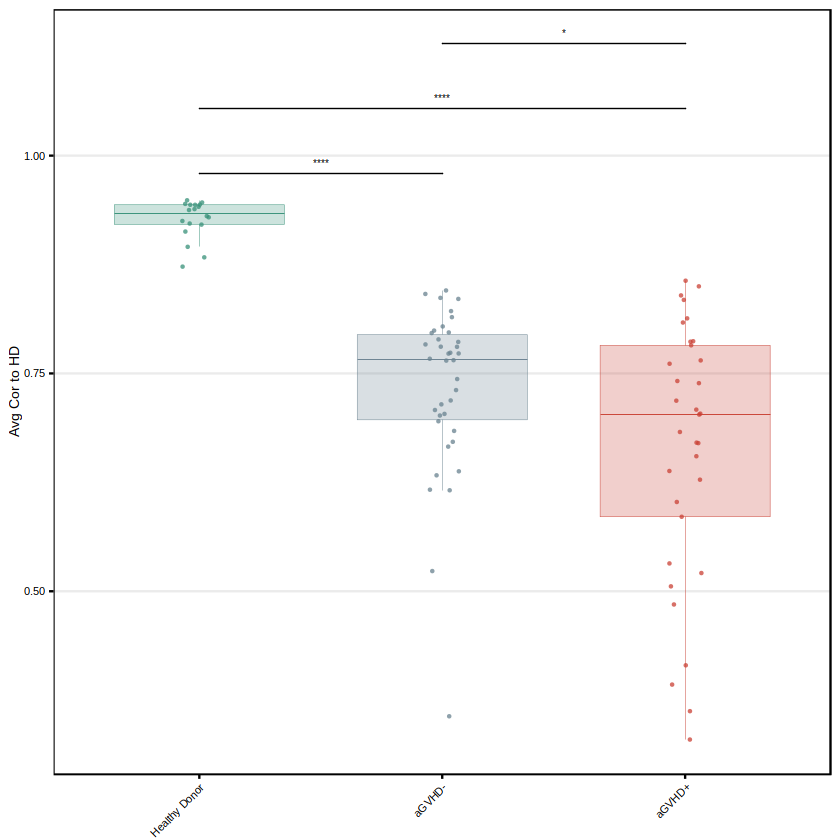

In [18]:
plot_list[[4]]

In [43]:
new_theme <- list(
    theme(axis.text.x = element_blank(),
        axis.title.x = element_text(size = 8, vjust = 5),
        axis.ticks.x = element_blank(),
        axis.title.y = element_blank())
)

YADD = 0.05

## timing
agvhd_timing_final = agvhd_timing + 
    scale_y_continuous(limits = c(0-((0.014*YADD)),0.014*(1+YADD)), breaks = c(0,0.007,0.014))+
    labs(y="Density",x="Days Post Transplant")+
    theme(axis.title.x = element_text(size = 8, vjust = 1.25),
        # axis.title.y = element_blank()
        )+
    geom_vline(xintercept = 10, linetype = "dashed", color = "black", size = 0.25)+
    geom_vline(xintercept = 20, linetype = "dashed", color = "black", size = 0.25)


## correlation
cor_plt = plot_list[[4]] + 
    labs(x = "Correlation to\nHealthy Donors") + 
    scale_y_continuous(limits = c(0.3,1.13), breaks = c(0.3, 0.65, 1),expand = c(YADD,YADD))+
    new_theme

## leukocyte
leuk_plt = plot_list[[1]] + 
    labs(x = "Leukocyte\nFraction") + 
    scale_y_continuous(limits = c(0,0.826), breaks = c(0, 0.4, 0.7),expand = c(YADD,YADD))+
    new_theme

## histone
hist_plt = plot_list[[5]] + 
    labs(x = "Histone\nTranscripts (CPM)")+
    scale_y_continuous(limits = c(0,70800), breaks = c(0, 30000, 60000),expand = c(0.1,0.1))+
    new_theme


### Align all plots
final_plot = agvhd_timing_final+
        plot_spacer()+
        cor_plt+leuk_plt+hist_plt+
        plot_layout(widths = c(1.75,0.05,1,1,1),nrow = 1)



WIDTH= 5.4
HEIGHT= 2

pdf(file="figures/aGVHD_toprow.pdf",
        width=WIDTH,height=HEIGHT, paper="special", bg="white",
        fonts="Helvetica", colormodel = "srgb", pointsize=6, useDingbats = FALSE)

print(final_plot)

dev.off()

Don't know how to automatically pick scale for object of type <difftime>.
Defaulting to continuous.


png 
  2

In [30]:
(1.13 - .3) / (0.7)

[1] 1.185714

In [35]:
60000 * 1.18

[1] 70800

In [31]:
60000 * 1.18

[1] 70800

In [84]:
sum(c(1.75,0.1,1,1,1))

[1] 4.85

In [85]:
5.3/4.85

[1] 1.092784

---
# DAA - aGVHD E

### Select samples

In [3]:
suppressMessages(library(DESeq2))
suppressMessages(library(pheatmap))
suppressMessages(library(pROC))


TIME = c("HD","E")
mdf_agvhd_daa <- mdf %>% 
    filter(timepoint %in% TIME) %>% 
    filter(rel_agvhd < 0 | is.na(rel_agvhd)) %>% 
    mutate(expGroup = case_when(agvhd == "Healthy Donor" ~ "HD",
                                agvhd == "aGVHD-" ~ "Neg",
                                agvhd == "aGVHD+" ~ "Pos")) %>%
    mutate(expGroup = factor(expGroup, levels = c("HD","Neg","Pos"))) 

table(mdf_agvhd_daa$expGroup)


### get counts
counts = read.delim("../1_DATA/counts_sQC_gAll_nRaw.tsv")
counts_daa = counts[,mdf_agvhd_daa$sample_id]

### get norm counts
counts_vst = read.delim("../1_DATA/counts_sQC_gAll_nVST.tsv")
counts_vst = counts_vst[,mdf_agvhd_daa$sample_id]


 HD Neg Pos 
 18  38  33 

### Run DESeq2

In [4]:
# #------------------------------------
# # Run DESeq
# dds <- DESeqDataSetFromMatrix(counts_daa,
#                                 colData = mdf_agvhd_daa,
#                                 design = ~ expGroup )

# # Normalize counts and estimate size factors
# dds <- estimateSizeFactors(dds)

# # Compute baseMean and filter genes
# baseMean_values <- rowMeans(counts(dds, normalized=TRUE))
# dds <- dds[baseMean_values > 5, ]

# dds <- DESeq(dds)


# dds %>% saveRDS("./outputs/DESEQ2_agvhdE.rds")

# ##------------------------------------
# ## Get Results
dds = readRDS("./outputs/DESEQ2_agvhdE.rds")
res <- results(dds, contrast=c("expGroup","Pos","Neg")) 

res_df <- res %>% data.frame()
res_df <- merge(res_df,gene_key, by.x=0, by.y="gene_id") %>% column_to_rownames(.,"Row.names")


##------------------------------------
## Add AUC
get_auc <- function(gene,counts,meta,VAR){
        gene_counts = counts[gene,,drop=FALSE] %>% t() 
        meta_wGene <- merge(meta, gene_counts,by.x="sample_id",by.y=0)
        roc_auc = roc(meta_wGene[[VAR]] ~ meta_wGene[[gene]], plot = FALSE, print.auc = FALSE, quiet=TRUE)
return(as.numeric(roc_auc$auc))}

all_sig_df <- res_df %>% filter(padj < 0.3) %>% rownames_to_column("gene_id")
tmp_mdf = mdf_agvhd_daa %>% filter(expGroup != "HD") %>% mutate(expGroup = as.character(expGroup))
tmp_counts_vst = counts_vst[,tmp_mdf$sample_id]
all_sig_df$gene_auc <- lapply(all_sig_df$gene_id, get_auc, tmp_counts_vst, tmp_mdf, "expGroup")

##------------------------------------
## save for IPA
res_df %>% write.csv("./outputs/aGVHD_E-ipaIN.csv",quote=FALSE)
res_df %>% write.csv("./outputs/hsct_cfrna_DataS1.csv",quote=FALSE)


In [16]:
res_df %>% filter(padj < 0.1) %>% nrow

[1] 296

### Heatmap

In [17]:
###########################
# HEATMAP
###########################

PADJ_THRESH = 0.1
BM_THRESH = 0 #50
LFC_THRESH = 0
AUC_THRESH = 0.65


CNTS = counts_vst

##---------------------
# get sig genes
sig_genes <- all_sig_df %>%
        filter(padj < PADJ_THRESH) %>%
        filter(!is.na(padj)) %>%
        filter(baseMean > BM_THRESH) %>%
        filter(abs(log2FoldChange) > LFC_THRESH) %>%
        filter(gene_auc > AUC_THRESH) %>% 
        pull(gene_id)

length(sig_genes)

##---------------------
# subset metadata and matrix
META = mdf_agvhd_daa %>% filter(expGroup != "HD") %>% select(sample_id, expGroup) %>% column_to_rownames("sample_id")
mat <- t(scale(t(CNTS[sig_genes,rownames(META)])))
mat <- mat[complete.cases(mat),]

##---------------------
# Prepare meta data and colors for annotations
mycolors <- list(expGroup = c("Pos" = COLORs[["aGVHD+"]],"Neg" = COLORs[["aGVHD-"]]))
color = colorRampPalette(c("blue","yellow"))(50)
breaksList = seq(-2, 2, length = 51)


##---------------------
# Plot
options(repr.plot.height = 6, repr.plot.width = 6)
heatmap_plt <- pheatmap(mat,
                        # Colors
                col=color,
                breaks=breaksList, 
                annotation_col= META %>% select(expGroup),
                annotation_colors=mycolors,
                # na_col = "#FFFFFF",

                # Fonts
                show_colnames=F,
                show_rownames=F,
                fontsize=12,
                fontsize_col=6,
                annotation_names_col=F,
                annotation_names_row=F,

                # Clustering
                treeheight_row=0,
                treeheight_col= 15,
                clustering_distance_cols = "correlation",

                # Misc.
                border_color=NA,
                legend=FALSE,
                silent = TRUE,
                annotation_legend=FALSE)

WIDTH = 2.5
HEIGHT = 4
RES = 300
png(file=paste0("figures/aGVHD_EHeatmap.plt.png"),
        width=WIDTH,height=HEIGHT, units ="in", bg="white", res = RES, #useRaster = TRUE,
        fonts="Helvetica",  pointsize=6)
print(heatmap_plt)
dev.off()

[1] 105

png 
  2

### IPA

png 
  2

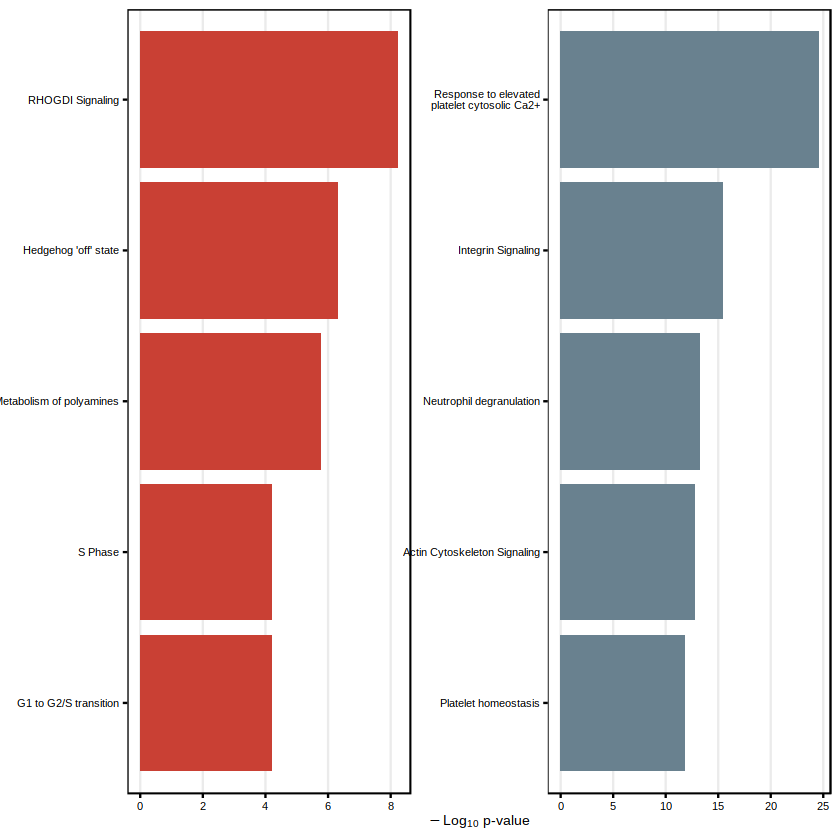

In [8]:
N = 5

# df = read.delim("./outputs/E_agvhdvsall.ipaOUT.txt",skip = 2)
df = read.delim("/workdir/cjl332/HCT_DFCI/PAPER2_cfrna/Figure3_aGVHD/outputs/agvhd_ipa_out.txt",skip = 2)

colnames(df) <- c("pathway","logpval","ratio","zscore","genes","X")


df <- df %>% 
        filter(abs(zscore) > 0.5) %>% 
    mutate(group=ifelse(zscore >0,"aGVHD+","aGVHD-")) %>% 
    # mutate(group=ifelse(zscore >0,"neg","pos")) %>% 
    filter(!is.na(group)) %>%
    arrange(desc(logpval))

df_1 <- df %>% filter(group == 'aGVHD+') %>% head(N)
df_2 <- df %>% filter(group == "aGVHD-") %>% head(N) #%>% arrange(logpval)

df <- rbind(df_1,df_2)

# df = df %>% mutate(pathway = ifelse(grepl("Cytokine Storm",pathway),"Pathogen Induced Cytokine\nStorm Signaling",pathway))
# df = df %>% mutate(pathway = ifelse(grepl("Class A/1",pathway),"Class A/1 (Rhodopsin-like receptors)",pathway))
# df = df %>% mutate(pathway = ifelse(grepl("IL-12",pathway),"Macrophage IL-12\nSignaling and Production",pathway))
df = df %>% mutate(pathway = ifelse(grepl("Response to elevated",pathway),"Response to elevated\nplatelet cytosolic Ca2+",pathway))
df = df %>% mutate(pathway = ifelse(grepl("alpha/beta",pathway),"Interferon alpha/beta\nsignaling",pathway))
df = df %>% mutate(pathway = ifelse(grepl("Interferon gamma",pathway),"Interferon gamma\nsignaling",pathway))
df = df %>% mutate(pathway = ifelse(grepl("Neutrophil degran",pathway),"Neutrophil degranulation",pathway))

df = df %>% mutate(pathway = ifelse(grepl("Mitotic G1",pathway),"G1 to G2/S transition",pathway))




order <- rev(df$pathway)


ipa_plt <- df %>% 
        mutate(group = factor(group, levels = c("aGVHD+","aGVHD-"))) %>%
        # mutate(group = factor(group, levels = c("aGVHD+"))) %>%
        filter(!is.na(group)) %>%

        mutate(pathway = factor(pathway, levels = order)) %>%
        ggplot(aes(x=logpval, y=pathway, fill = group))+
        geom_bar(stat="identity")+
        theme_cfrna_print()+
        facet_wrap(~group, scales = "free", ncol = 2)+
        labs(x=bquote(-Log[10]*" p-value"))+

        theme_cfrna_print() +
        theme(
                axis.title.y = element_blank(),
                legend.position = "none",
                panel.grid.minor.y = element_blank(),       # Remove minor gridlines
                strip.background = element_blank(),
                strip.text = element_blank(),
                panel.grid.minor.x = element_blank(),
                panel.grid.major.y = element_blank()
        )+
        scale_fill_manual(values = COLORs)

print(ipa_plt)
WIDTH= 4
HEIGHT= 1.45

pdf(file="figures/aGVHD_E-ipa.top6.pdf",
        width=WIDTH,height=HEIGHT, paper="special", bg="white",
        fonts="Helvetica", colormodel = "srgb", pointsize=6, useDingbats = FALSE)
ipa_plt
dev.off()

### Volacno - old

In [25]:
res_df %>% filter(log2FoldChange<0) %>% arrange(padj) %>% head(3)
res_df %>% filter(log2FoldChange<0) %>% arrange(log2FoldChange) %>% head(3)

# res_df %>% filter(log2FoldChange>0) %>% arrange(padj) %>% head(3)
res_df %>% filter(log2FoldChange>0) %>% arrange(desc(log2FoldChange)) %>% head(3)


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_name,gene_type
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
ENSG00000100427.16,169.2116,-1.3575270,0.3367777,-4.030930,5.555667e-05,0.05788125,MLC1,protein_coding
ENSG00000109906.15,104.4191,-0.8125459,0.2027516,-4.007594,6.134051e-05,0.05788125,ZBTB16,protein_coding
ENSG00000166831.9,235.0194,-1.1140663,0.2804617,-3.972258,7.119465e-05,0.05788125,RBPMS2,protein_coding


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_name,gene_type
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
ENSG00000177508.12,10.236807,-1.959004,0.3973631,-4.930012,8.222472e-07,NA,IRX3,protein_coding
ENSG00000244921.2,7.726017,-1.822329,0.6980450,-2.610619,9.037856e-03,NA,MTCYBP18,processed_pseudogene
ENSG00000279928.2,27.018655,-1.628396,0.4404308,-3.697279,2.179225e-04,NA,DDX11L17,unprocessed_pseudogene


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_name,gene_type
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
ENSG00000225972.1,30.274207,2.242141,0.4741176,4.729083,2.255360e-06,NA,MTND1P23,unprocessed_pseudogene
ENSG00000228981.3,5.964239,1.765077,0.5689970,3.102085,1.921631e-03,NA,RP11-364L4.1,processed_pseudogene
ENSG00000262902.1,18.260630,1.507238,0.4147921,3.633720,2.793641e-04,NA,MTCO1P40,processed_pseudogene


Warning message in geom_text_repel(size = 2, max.overlaps = Inf, min.segment.length = 0, :
“Ignoring unknown parameters: `fill`”


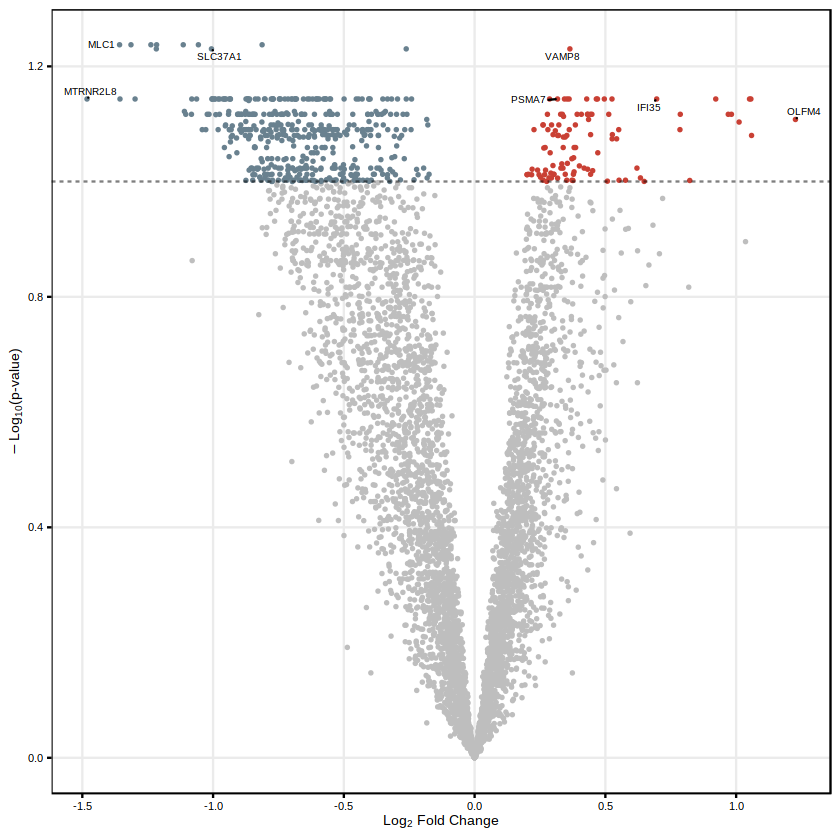

In [26]:
library(ggrepel)

PADJ_THRESH = 0.1
LFC_THRESH = 0

### extract results and label "up", "down", "notsig"
detable <- res_df %>%
    mutate(sig_dir = case_when(
        padj<PADJ_THRESH & log2FoldChange > LFC_THRESH ~ "up",
        padj<PADJ_THRESH & log2FoldChange < -LFC_THRESH  ~"down",
        .default = "notsig"))

GENEs = c("IFI35","PSMA7","VAMP8","OLFM4","MLC1","MTRNR2L8","SLC37A1")
top_all = c(GENEs)

detable <- detable %>% mutate(delabel = ifelse(gene_name %in% top_all,gene_name,""))

# create plot
vol_plt <- detable %>% 
    # filter(baseMean > 50) %>% 
    # filter(gene_type == "protein_coding") %>% 
    filter(!is.na(padj)) %>%
    ggplot(aes(x=log2FoldChange, y=-log10(padj), color = sig_dir, label=delabel)) + #
    geom_point(size = 0.5) +
    geom_hline(yintercept = -log10(PADJ_THRESH), size = 0.5, alpha = 0.5, linetype="dashed")+
    # geom_vline(xintercept = c(-LFC_THRESH, LFC_THRESH), size = 0.5, alpha = 0.5, linetype="dashed") + 
    geom_text_repel(size = 2, 
        max.overlaps=Inf, 
        min.segment.length = 0, 
        color = "black", 
        fill="white",
        box.padding = 0.1
        # xlim = c(-Inf, Inf), ylim = c(-Inf, Inf)
        ) +
    theme_cfrna_print() +
    theme(
      legend.position = "none",
      panel.grid.minor.y = element_blank(),       # Remove minor gridlines
      panel.grid.minor.x = element_blank()        # Remove major x gridlines
    )+
    labs(x = bquote(Log[2]*" Fold Change"), y= bquote(-Log[10]*"(p-value)")) +
    # coord_cartesian(xlim = c(-2.5,2.5), ylim = c(0, 1.75),clip = "off") +
    scale_color_manual(values = c("notsig"="grey","up"=COLORs[["aGVHD+"]],"down"=COLORs[["aGVHD-"]]))# +

vol_plt

WIDTH = 2
HEIGHT = 2

ggsave("figures/aGVHD_VOLCANO_E.plt.pdf", vol_plt, width = WIDTH, height = HEIGHT, dpi = 300)

### gene plots

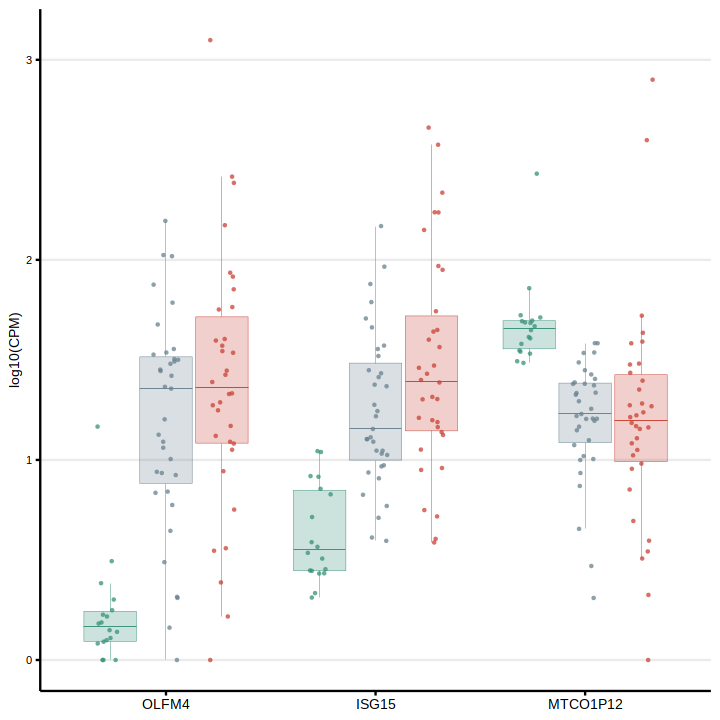

In [32]:

GENEs = c("GBP1","OLFM4","IFI35","SAMD14","SLC24A3","TMEM64")

GENEs = c("VAMP8","CHCHD7","PSMA7")
# GENEs = c("SLC24A3","SAMD14","MLC1")





GENEIDS = gene_key %>% filter(gene_name %in% GENEs) %>% pull(gene_id)

### Normalize counts
CNTS = edgeR::cpm(counts_daa)

### Combine counts with metadata
cnt_df = merge(mdf_agvhd_daa %>% select(sample_id, date_agvhd, agvhd), 
        data.frame(t(CNTS[GENEIDS,])),
        by.x="sample_id",by.y=0) %>% 
    reshape2::melt(id.vars = c("sample_id","date_agvhd","agvhd"), variable.name = "gene_id",value.name = "counts")

### Add gene names for plotting
cnt_df = merge(cnt_df, gene_key, by.x="gene_id", by.y="gene_id") %>% 
    mutate(gene_name = factor(gene_name, levels = GENEs))

### Make plot
set.seed(42)
cnt_df %>% 
    ggplot(aes(x=gene_name, y=log10(counts+1), fill = agvhd, color = agvhd))+
    geom_boxplot(outlier.shape = NA, position = position_dodge(width = 0.8), alpha = 0.25, size = 0.1) +
    geom_point(size = 1, alpha = 0.75, stroke=NA,
              position =  position_jitterdodge(jitter.height=0, 
                                                jitter.width=.3, 
                                                dodge.width = 0.8, 
                                                seed=42)
                )+
    theme_cfrna_print()+
    labs(y = "log10(CPM)")+
    theme(
        axis.text.x = element_text(size = 8),
        axis.title.x = element_blank(),
        panel.border = element_blank(),                  # Remove all borders initially
        axis.line = element_line(),                      # Add back the bottom and left lines
        axis.line.x.top = element_blank(),               # Ensure top border is removed
        axis.line.y.right = element_blank(),             # Ensure right border is removed
        panel.grid.minor = element_blank(),             # Remove minor gridlines
        panel.grid.major.x = element_blank()             # Remove major gridlines
        )+
    scale_fill_manual(values = COLORs)+
    scale_color_manual(values = COLORs)

### Save
WIDTH = 2.5
HEIGHT= 1.7

ggsave("figures/aGVHD_EGenes.pdf", width=WIDTH, height=HEIGHT, units="in")

---
# DAA - aGVHD Longitudinal

### Select samples

In [5]:
suppressMessages(library(DESeq2))
suppressMessages(library(pheatmap))
suppressMessages(library(pROC))


TIME = c("E","1M","2M")

mdf_agvhd_daa <- mdf %>% filter(ORIGIN == "DFCI") %>%
    filter(timepoint %in% TIME) %>% 
    filter(rel_agvhd < 0 | is.na(date_agvhd))

mdf_agvhd_daa$rel_agvhd <- as.numeric(mdf_agvhd_daa$rel_agvhd)

summary(mdf_agvhd_daa$rel_agvhd)

### get counts
counts = read.delim("../1_DATA/counts_sQC_gAll_nRaw.tsv")
counts_daa = counts[,mdf_agvhd_daa$sample_id]

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
-301.00 -131.50  -56.00  -79.31  -18.50   -3.00     114 

### Run DESeq2

In [7]:
##------------------------------------
## Run DESeq

# mdf_aghvd_only = mdf_agvhd_daa %>% filter(!is.na(date_agvhd))
# counts_agvhd_only = counts[,mdf_aghvd_only$sample_id]

# dds <- DESeqDataSetFromMatrix(counts_agvhd_only,
#                                 colData = mdf_aghvd_only,
#                                 design = ~ timepoint + rel_agvhd )

# dds <- DESeq(dds)

# # Normalize counts and estimate size factors
# dds <- estimateSizeFactors(dds)

# # Compute baseMean and filter genes
# baseMean_values <- rowMeans(counts(dds, normalized=TRUE))
# dds <- dds[baseMean_values > 5, ]


# dds %>% saveRDS("./outputs/DESEQ2_agvhdE.LONG.rds")

##------------------------------------
## Get Results
dds = readRDS("./outputs/DESEQ2_agvhdE.LONG.rds")
res <- results(dds) 

res_df <- res %>% data.frame()
res_df <- merge(res_df,gene_key, by.x=0, by.y="gene_id") %>% column_to_rownames(.,"Row.names")

res_df %>% write.csv("./outputs/hsct_cfrna_DataS2.csv",quote=FALSE)


In [6]:
res_df %>% filter(padj < 0.1) %>% nrow

[1] 296

In [59]:
res_df %>% filter(grepl("^HLA",gene_name)) %>% filter(padj < 0.1)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_name,gene_type
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
ENSG00000204525.17,3097.083,0.005409569,0.001547181,3.496403,0.0004715758,0.06484829,HLA-C,protein_coding
ENSG00000204592.9,6097.044,0.005471662,0.001728140,3.166215,0.0015443636,0.08312731,HLA-E,protein_coding
ENSG00000206503.13,2622.310,0.005977573,0.001677921,3.562487,0.0003673579,0.06484829,HLA-A,protein_coding
ENSG00000234745.13,4980.892,0.005087824,0.001659548,3.065790,0.0021709584,0.08856822,HLA-B,protein_coding


In [61]:
GENEs = c("HLA-A","HLA-B","HLA-C","HLA-E")

GENEIDS = gene_key %>% filter(gene_name %in% GENEs) %>% pull(gene_id)

### Normalize counts
CNTS = edgeR::cpm(counts_daa)

### Combine counts with metadata
cnt_df = merge(mdf_agvhd_daa %>% select(sample_id, date_agvhd, rel_agvhd, timepoint, Record_ID), 
        data.frame(t(CNTS[GENEIDS,])),
        by.x="sample_id",by.y=0) %>% 
    reshape2::melt(id.vars = c("sample_id","date_agvhd","rel_agvhd","timepoint", "Record_ID"), variable.name = "gene_id",value.name = "counts")
cnt_df = merge(cnt_df, gene_key, by.x="gene_id", by.y="gene_id") %>% 
    mutate(gene_name = factor(gene_name, levels = GENEs)) 

In [64]:
for (G in GENEs){
    cat(G,"\n")
    cnt_df_G = cnt_df %>% filter(gene_name == G)
    cor.test(cnt_df_G$rel_agvhd, cnt_df_G$counts) %>% print()
    cat("-------------\n")
}

HLA-A 

	Pearson's product-moment correlation

data:  cnt_df_G$rel_agvhd and cnt_df_G$counts
t = 2.7653, df = 69, p-value = 0.007291
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.08911951 0.51146936
sample estimates:
     cor 
0.315856 

-------------
HLA-B 

	Pearson's product-moment correlation

data:  cnt_df_G$rel_agvhd and cnt_df_G$counts
t = 2.2821, df = 69, p-value = 0.02557
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.03370087 0.46922395
sample estimates:
      cor 
0.2649216 

-------------
HLA-C 

	Pearson's product-moment correlation

data:  cnt_df_G$rel_agvhd and cnt_df_G$counts
t = 3.1793, df = 69, p-value = 0.002211
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.1354475 0.5452848
sample estimates:
      cor 
0.3574555 

-------------
HLA-E 

	Pearson's product-moment correlation

data:  cnt_df_G$rel_agvhd and cnt_df_G$counts
t = 3.

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 456 rows containing non-finite outside the scale range
(`stat_smooth()`).”


Warning message:
“Removed 456 rows containing missing values or values outside the scale range
(`geom_point()`).”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 456 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 456 rows containing missing values or values outside the scale range
(`geom_point()`).”


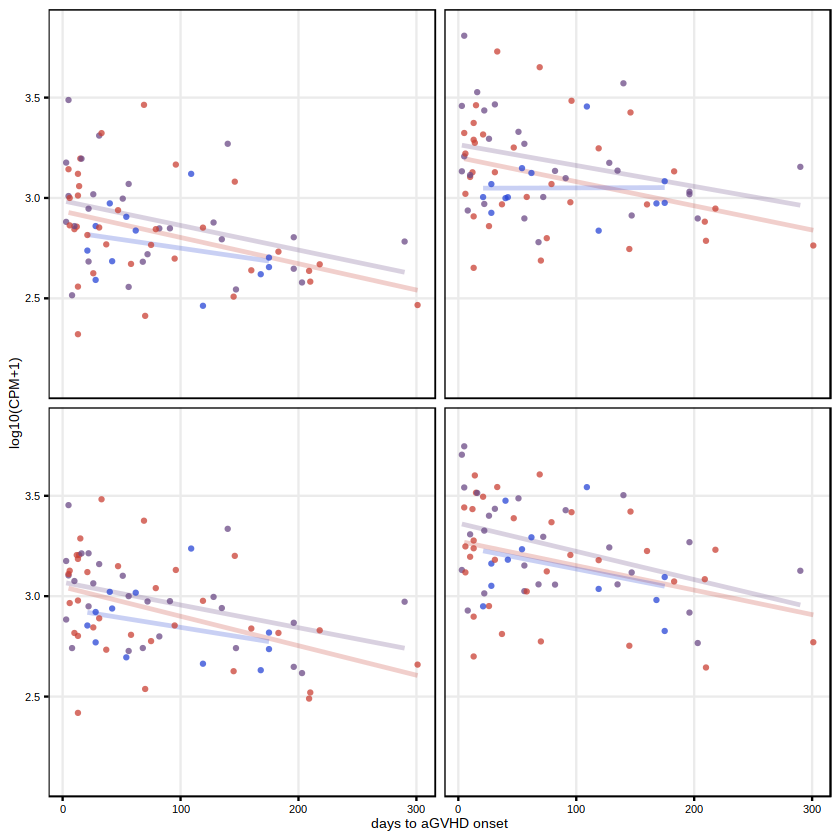

In [59]:
COLS = c("E" = COLORs[["aGVHD+"]], "1M" = "#6B4A86", "2M" = "#2846D5")
cnt_df %>% 
    ggplot(aes(x=-rel_agvhd, y=log10(counts+1), color = timepoint))+
    geom_line(stat="smooth",method = "lm",
            # color = "black",
            size = 1,alpha = 0.25)+
    geom_point(size = 1.5, alpha = 0.75, stroke=NA)+
    facet_wrap(~gene_name, nrow=2)+
        theme_cfrna_print()+
    labs(y = "log10(CPM+1)", x= "days to aGVHD onset")+
    scale_color_manual(values = COLS )+
    theme(
      panel.grid.minor.x = element_blank()        # Remove major x gridlines
    )

### Save
WIDTH = 2.55
HEIGHT = 2.5

ggsave("figures/aGVHD_corGenes.pdf", width=WIDTH, height=HEIGHT, units="in")

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 456 rows containing non-finite outside the scale range
(`stat_smooth()`).”


Warning message:
“Removed 456 rows containing missing values or values outside the scale range
(`geom_point()`).”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 456 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 456 rows containing missing values or values outside the scale range
(`geom_point()`).”


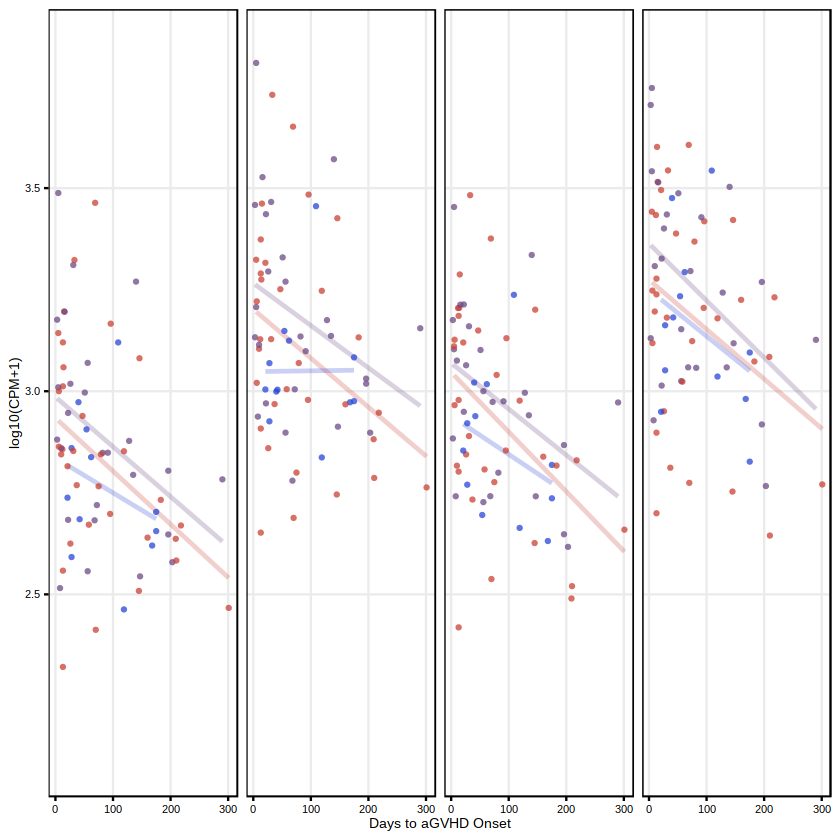

In [65]:
COLS = c("E" = COLORs[["aGVHD+"]], "1M" = "#6B4A86", "2M" = "#2846D5")
cnt_df %>% 
    ggplot(aes(x=-rel_agvhd, y=log10(counts+1), color = timepoint))+
    geom_line(stat="smooth",method = "lm",
            # color = "black",
            size = 1,alpha = 0.25)+
    geom_point(size = 1.5, alpha = 0.75, stroke=NA)+
    facet_wrap(~gene_name, nrow=1)+
        theme_cfrna_print()+
    labs(y = "log10(CPM+1)", x= "Days to aGVHD Onset")+
    scale_color_manual(values = COLS )+
    # theme(legend.position =  "right")
    theme(
      panel.grid.minor.x = element_blank()        # Remove major x gridlines
    )

### Save
WIDTH = 5.1
HEIGHT = 1.5

ggsave("figures/aGVHD_corGenes.pdf", width=WIDTH, height=HEIGHT, units="in")

### survivor plot

In [143]:
library(survminer)
library(lubridate)

In [149]:
gene_cnts %>% pull(rel_agvhd)

[1]  NA 168 290  NA  96  NA  95  62  NA  NA  NA  15  26 301  13  NA  NA  NA
 [19]  54  NA   5  13  NA  NA  NA  NA  NA  NA  NA  31  NA  NA  NA  37  14   5
 [37]   3  40  NA  NA  NA  10  75 109  NA 146  NA  NA   5   8  68 140  NA  91
 [55]  NA  NA  NA  NA  NA 209  82  NA 196  NA  NA  13  NA   3 175 218  NA  NA
 [73]  NA  21  NA 119  NA  NA  NA  NA  NA  NA  NA  NA  NA  NA 183  12  47  NA
 [91]  NA  NA  NA  NA  NA  NA  10  NA  22  69  NA 175  NA  33  56  NA  NA  NA
[109] 203 210  NA 135  28  NA  NA  NA  NA  16  NA 145  22  NA  NA  13  NA  NA
[127]  NA   6  NA 147  56  28  NA  NA  NA  NA  NA 160 119  NA  70  NA  NA  NA
[145]  NA  NA  NA  48  NA  NA  83  NA  NA  NA  NA  NA  NA  NA  NA  NA  NA  NA
[163]  NA  NA  NA  NA  NA  NA  79 128   6  51  72  NA  NA  NA  26  NA  NA  NA
[181]  42  NA 196  58  31  21  NA

In [164]:
### for reach GENE plot correlation and KM curve

PLOTs = list()

for (GENE in GENEs){

    gene_cnts = cnt_df %>% filter(gene_name == GENE) 
    median_value = median(gene_cnts$counts, na.rm = TRUE)
    gene_cnts = gene_cnts %>% 
        mutate(quant = ifelse(counts >= median_value, "high","low")) %>% 
        mutate(rel_agvhd = -rel_agvhd)


    ### COR PLOT
    cor_plt = gene_cnts %>% 
        ggplot(aes(x=rel_agvhd, y=log10(counts+1), color = timepoint))+
        geom_point(size = 1.5, alpha = 0.75, stroke=NA)+
        facet_wrap(~gene_name, nrow=1, scales = "free")+
            theme_cfrna_print()+
        labs(y = "log10(CPM+1)", x= "days to aGVHD onset")+
        theme(
            legend.position = "none",
            strip.text = element_text(size=8),
            strip.background = element_blank()
            )+
        scale_color_manual(values = COLS )+
        theme(
        axis.title = element_blank(),
        panel.border = element_blank(),             # Remove all borders initially
        axis.line = element_line(),                 # Add back the bottom and left lines
        axis.line.x.top = element_blank(),          # Ensure top border is removed
        axis.line.y.right = element_blank(),        # Ensure right border is removed
        panel.grid.minor.y = element_blank(),       # Remove minor gridlines
        panel.grid.minor.x = element_blank()        # Remove major x gridlines
        )+
        guides(color = guide_legend(title.hjust = 0                                           # Fine-tune title horizontal alignment))
        ))

    ## SURVIVAL PLOT
    # Replace NA in failure_days with an appropriate censoring indicator
    gene_cnts$censor = ifelse(is.na(gene_cnts$rel_agvhd),0,1)

    # Replace NA in failure_days with some large value (to ensure censored individuals are included in the survival calculation):
    MAX_DAYS <- max(gene_cnts$rel_agvhd, na.rm = TRUE)
    gene_cnts$rel_agvhd[is.na(gene_cnts$rel_agvhd)] <- MAX_DAYS + 1

    # Create the survival object
    surv_obj <- survival::Surv(time = gene_cnts$rel_agvhd, event = gene_cnts$censor)

    # Fit the survival curve, split by the 'quant' group
    fit <- survival::survfit(surv_obj ~ quant, data = gene_cnts)

    # Plot the KM curve with censoring information
    km_plt <- ggsurvplot(fit, data = gene_cnts, 
            #    legend.title = "Classifier Score:", 
            #    legend.labs = c("Low",  "High"),
                legend = "none",
            xlab = "Days", 
            ylab = "Survival Probability",
            conf.int = TRUE,
            censor = TRUE,          # Show censoring marks
            pval = FALSE, 
            risk.table = FALSE,      # Add risk table below the plot
            xlim = c(0,MAX_DAYS+100),
            ggtheme = theme_cfrna_print())

    PLOTs[[paste0(GENE,"_cor")]] = cor_plt
    PLOTs[[paste0(GENE,"_km")]] = km_plt

}

Warning message:
“Removed 114 rows containing missing values or values outside the scale range
(`geom_point()`).”


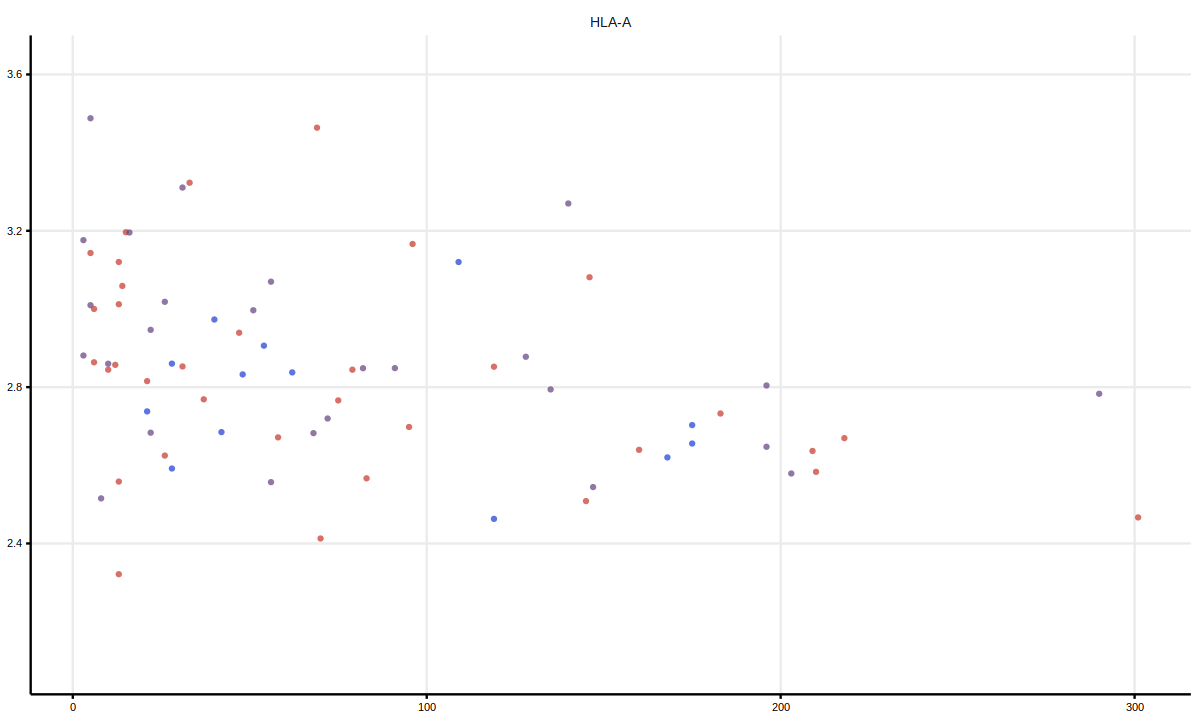

Warning message:
“Removed 114 rows containing missing values or values outside the scale range
(`geom_point()`).”


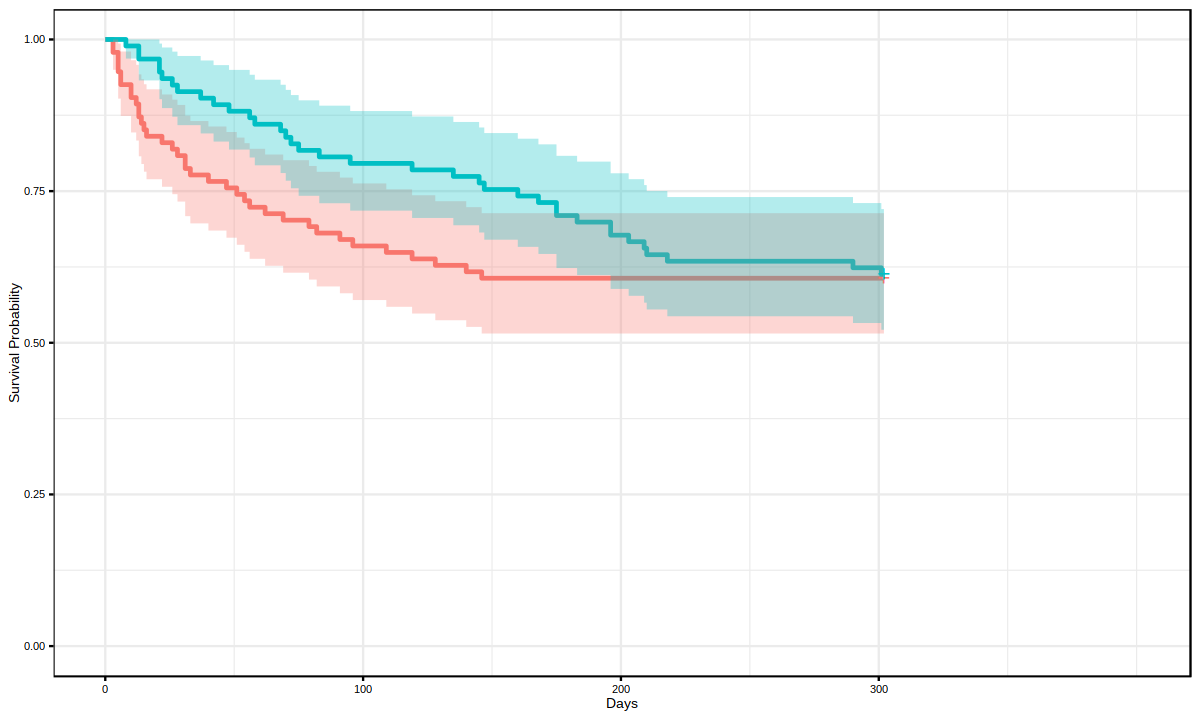

$`HLA-A_cor`

$`HLA-A_km`

$`HLA-C_cor`

$`HLA-C_km`


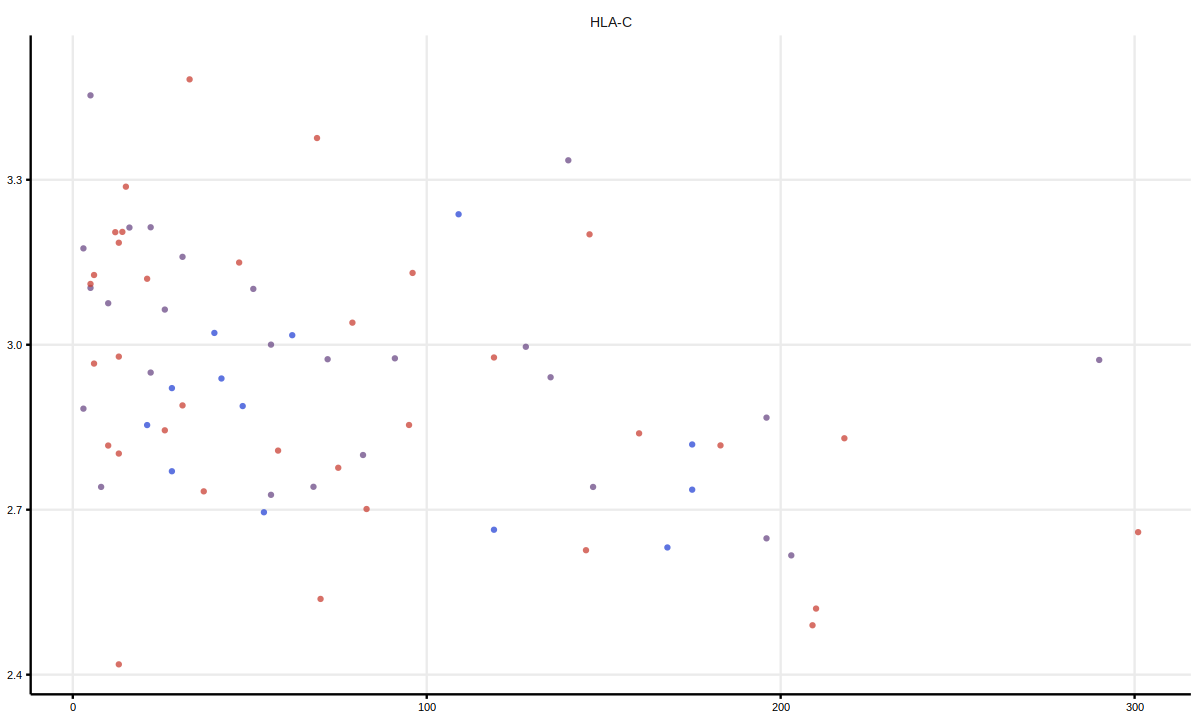

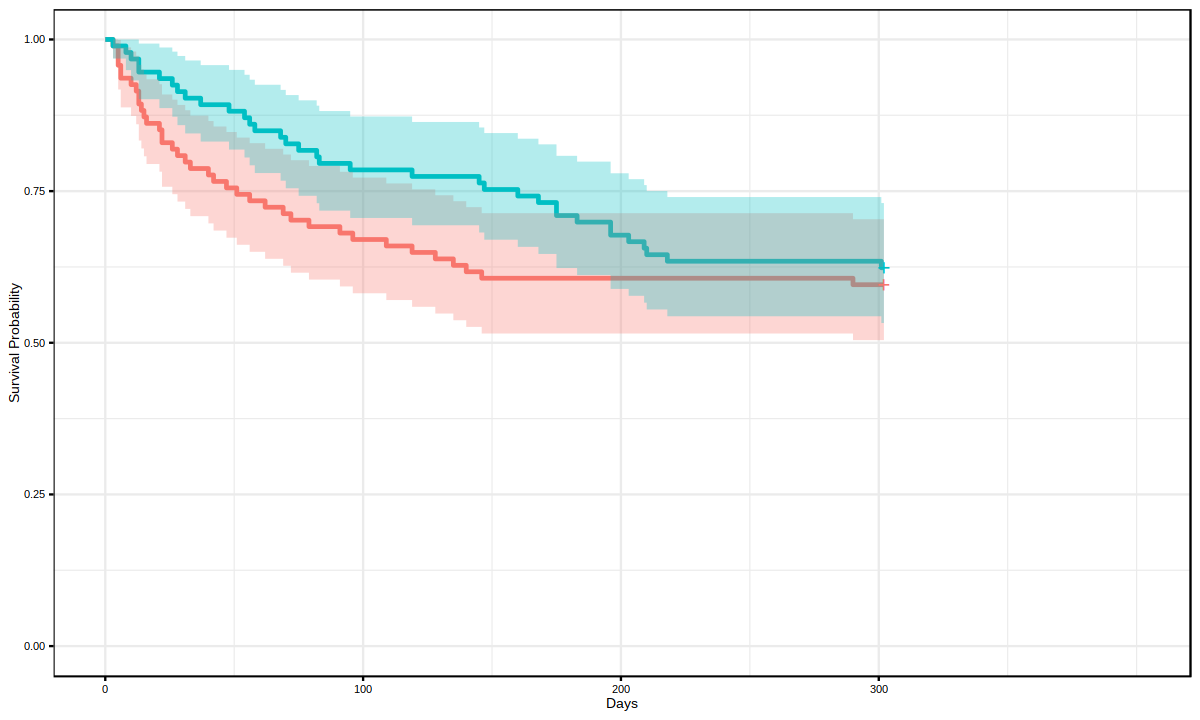

In [165]:
PLOTs

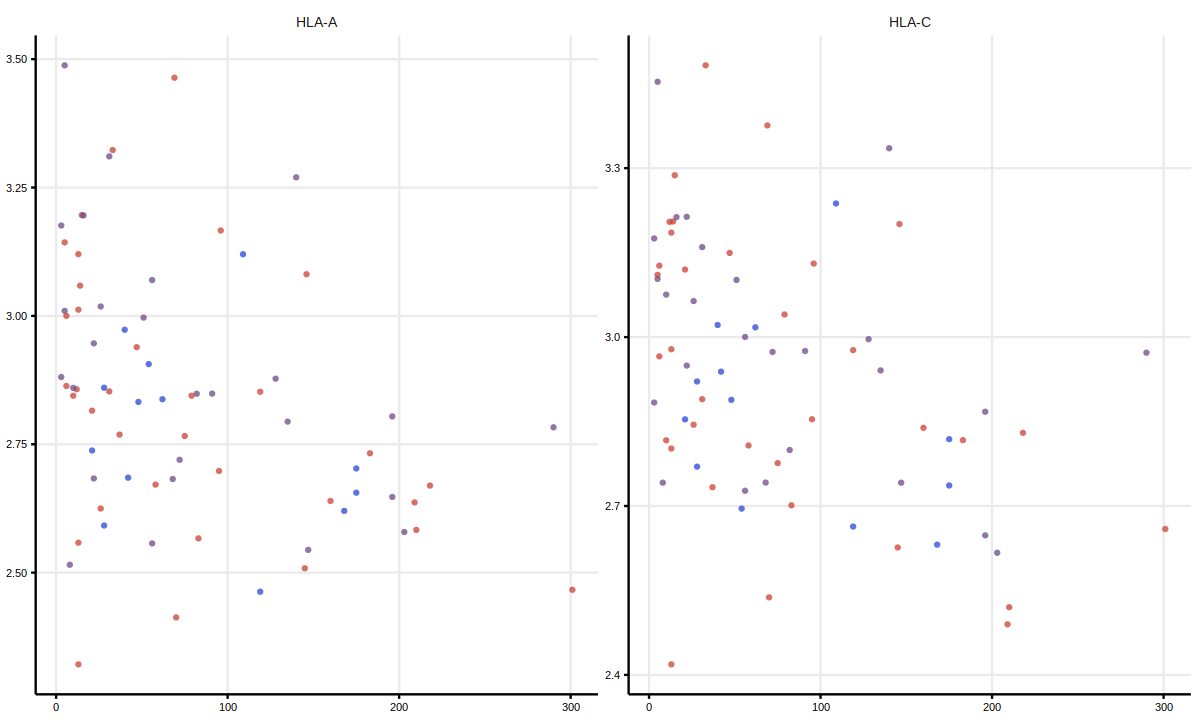

In [127]:
COLS = c("E" = COLORs[["aGVHD+"]], "1M" = "#6B4A86", "2M" = "#2846D5")
cnt_df %>% 
    ggplot(aes(x=-rel_agvhd, y=log10(counts+1), color = timepoint))+
    geom_point(size = 1.5, alpha = 0.75, stroke=NA)+
    facet_wrap(~gene_name, nrow=1, scales = "free")+
        theme_cfrna_print()+
    labs(y = "log10(CPM+1)", x= "days to aGVHD onset")+
    theme(
        legend.position = "none",
        strip.text = element_text(size=8),
        strip.background = element_blank()
        )+
    scale_color_manual(values = COLS )+
    theme(
      axis.title = element_blank(),
      panel.border = element_blank(),             # Remove all borders initially
      axis.line = element_line(),                 # Add back the bottom and left lines
      axis.line.x.top = element_blank(),          # Ensure top border is removed
      axis.line.y.right = element_blank(),        # Ensure right border is removed
      panel.grid.minor.y = element_blank(),       # Remove minor gridlines
      panel.grid.minor.x = element_blank()        # Remove major x gridlines
    )+
    guides(color = guide_legend(title.hjust = 0                                           # Fine-tune title horizontal alignment))
    ))

### Save
WIDTH = 3.5
HEIGHT=2

ggsave("figures/aGVHD_corGenes.pdf", width=WIDTH, height=HEIGHT, units="in")

---
# Modeling

In [46]:
library(edgeR)

TIME = c("E")
mdf_agvhd <- mdf %>% 
    filter(timepoint %in% TIME) %>% 
    filter(rel_agvhd < 0 | is.na(rel_agvhd)) %>% 
    mutate(agvhd = case_when(
            !is.na(date_agvhd) & timepoint != "HD" ~ "aGVHD+",
            is.na(date_agvhd) & timepoint != "HD" ~ "aGVHD-",
            timepoint == "HD" ~ "HD")) %>%
    mutate(agvhd = factor(agvhd, levels = c("HD","aGVHD-","aGVHD+"))) %>% 
    mutate(expGroup = case_when(agvhd == "HD" ~ "HD",
                                agvhd == "aGVHD-" ~ "Neg",
                                agvhd == "aGVHD+" ~ "Pos")) %>%
    mutate(expGroup = factor(expGroup, levels = c("HD","Neg","Pos"))) 


counts = read.delim("../1_DATA/counts_sQC_gAll_nRaw.tsv")
counts = counts[,mdf_agvhd$sample_id]


dge = DGEList(counts = counts)
dge = calcNormFactors(dge, method = "TMM")
cpm_values = cpm(dge, log = TRUE)

cpm_values %>% write.csv("./modeling/modeling_counts_cpm_tmm_log.csv", row.names=TRUE, quote=FALSE)
mdf_agvhd %>% mutate(expGroup = ifelse(expGroup == "Pos",1,0)) %>% write.csv("./modeling/modeling_metadata.csv",row.names=FALSE,quote=FALSE)

Loading required package: limma


Attaching package: ‘limma’


The following object is masked from ‘package:DESeq2’:

    plotMA


The following object is masked from ‘package:BiocGenerics’:

    plotMA




In [74]:
num_t = ncol(cpm_values) * .75

over50 = res_df %>% rownames()


thresh = rowSums(cpm_values > 3) %>% data.frame() %>% 
    dplyr::rename(.,cpm_over = `.`) %>% 
    mutate(passCPM = ifelse(cpm_over > num_t,1,0)) %>% 
    mutate(pass50 = ifelse(rownames(.) %in% over50,1,0))

table(thresh$passCPM, thresh$pass50)

   
        0     1
  0 49527   187
  1  1043  5914

In [ ]:
over50 = res_df %>% rownames()

In [68]:
res_df %>% head

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_name,gene_type
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
ENSG00000000419.14,53.30830,0.1248034,0.1133318,1.1012214,0.270800309,0.4833683,DPM1,protein_coding
ENSG00000000460.17,68.49621,-0.4718660,0.2557759,-1.8448416,0.065060580,0.2174984,C1orf112,protein_coding
ENSG00000000938.13,434.05415,0.1896194,0.1388155,1.3659820,0.171944626,0.3761327,FGR,protein_coding
ENSG00000001084.13,163.28859,0.2035855,0.2301882,0.8844305,0.376463876,0.5822069,GCLC,protein_coding
ENSG00000001167.15,92.29387,-0.1243816,0.1019353,-1.2202010,0.222388686,0.4316932,NFYA,protein_coding
ENSG00000001461.17,99.43445,-0.7482724,0.2382219,-3.1410736,0.001683297,0.0474641,NIPAL3,protein_coding


---
# DAA - PED

### Select samples

In [20]:
suppressMessages(library(DESeq2))
suppressMessages(library(pheatmap))
suppressMessages(library(pROC))


TIME = c("E","1M")
mdf_agvhd_daa <- mdf %>% 
    filter(timepoint %in% TIME) %>% 
    ## DFCI filters
    mutate(PredEqui_01 = ifelse(is.na(PredEqui_01), 0, PredEqui_01)) %>%
    ## remove samples with cGVHD
    filter(rel_agvhd < 0 | is.na(rel_agvhd)) %>% 
    mutate(agvhd = case_when(
            !is.na(date_agvhd) & timepoint != "HD" ~ "aGVHD+",
            is.na(date_agvhd) & timepoint != "HD" ~ "aGVHD-",
            timepoint == "HD" ~ "HD")) %>%
    mutate(agvhd = factor(agvhd, levels = c("HD","aGVHD-","aGVHD+"))) %>% 
    mutate(expGroup = PredEqui_01) %>%
    mutate(expGroup = factor(expGroup, levels = c(1,0))) 


table(mdf_agvhd_daa$expGroup)

### get counts
counts = read.delim("../1_DATA/counts_sQC_gAll_nRaw.tsv")
counts_daa = counts[,mdf_agvhd_daa$sample_id]



 1  0 
 6 63 

### Run DESeq2

In [22]:
##------------------------------------
## Run DESeq
# dds <- DESeqDataSetFromMatrix(counts_daa,
#                                 colData = mdf_agvhd_daa,
#                                 design = ~ expGroup )
# dds <- DESeq(dds)
# dds %>% saveRDS("./outputs/DESEQ2_agvhdE.rds")

##------------------------------------
## Get Results
# dds = readRDS("./outputs/DESEQ2_agvhdE.rds")
res <- results(dds, contrast=c("expGroup",1,0)) 

res_df <- res %>% data.frame()
res_df <- merge(res_df,gene_key, by.x=0, by.y="gene_id") %>% column_to_rownames(.,"Row.names")


##------------------------------------
## Add AUC
get_auc <- function(gene,counts,meta,VAR){
        gene_counts = counts[gene,,drop=FALSE] %>% t() 
        meta_wGene <- merge(meta, gene_counts,by.x="sample_id",by.y=0)
        roc_auc = roc(meta_wGene[[VAR]] ~ meta_wGene[[gene]], plot = FALSE, print.auc = FALSE, quiet=TRUE)
return(as.numeric(roc_auc$auc))}

all_sig_df <- res_df %>% filter(padj < 0.3) %>% rownames_to_column("gene_id")
tmp_mdf = mdf_agvhd_daa %>% filter(expGroup != "HD") %>% mutate(expGroup = as.character(expGroup))
tmp_counts_vst = counts_vst[,tmp_mdf$sample_id]
all_sig_df$gene_auc <- lapply(all_sig_df$gene_id, get_auc, tmp_counts_vst, tmp_mdf, "expGroup")

##------------------------------------
## save for IPA
res_df %>% filter(baseMean > 50) %>% write.csv("./outputs/aGVHD_E-ipaIN.csv",quote=FALSE)

ERROR: Error in `[.data.frame`(counts_vst, , tmp_mdf$sample_id): undefined columns selected


In [23]:
res_df %>% head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_name,gene_type
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
ENSG00000000419.14,58.64498,0.110816540,0.2063596,0.537006858,0.5912629,0.9999862,DPM1,protein_coding
ENSG00000000457.14,25.25579,0.295511647,0.2096250,1.409715945,0.1586236,0.9999862,SCYL3,protein_coding
ENSG00000000460.17,67.03903,-0.064378616,0.5013337,-0.128414710,0.8978208,0.9999862,C1orf112,protein_coding
ENSG00000000938.13,567.39364,0.069252987,0.2361550,0.293252266,0.7693293,0.9999862,FGR,protein_coding
ENSG00000000971.16,18.24789,0.004929474,0.5137114,0.009595805,0.9923438,0.9999862,CFH,protein_coding
ENSG00000001036.14,29.93325,0.102230732,0.2548885,0.401080211,0.6883611,0.9999862,FUCA2,protein_coding


In [24]:
res_df %>% filter(padj < 0.1) %>% nrow

[1] 2